## Iran Job Market Analysis
###  Project Overview
This project analyzes the Iranian job market by collecting thousands of job advertisements from JobVision.
The primary objective is to explore hiring trends, required technical skills, salary ranges, experience requirements, and regional demand across software engineering and data-related positions.
The analysis will also prepare the dataset for subsequent machine learning tasks and predictive modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

DATA_PATH = "../data/processed/jobs_clean.csv"


In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,keyword,job_id,title,company,province,city,salary_visible,experience_years,description,work_type,seniority,category,company_size,industries,benefits,salary_title,salary_min,salary_max,gender,required_age_min,required_age_max,military,work_days,business_trip,software,software_levels,first_activation,activation,expire,application_count,internship,remote,urgent
0,python,1396130,برنامه نویس Python,بارکس,تهران,تهران,False,5,ما برای توسعه ERP شرکت بر پایه Odoo به دنبال یک توسعه‌دهنده مسلط هستیم که توانایی توسعه ماژول‌ها...,Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Transportation / Logistics,"Loan,Bonus,Snacks\r\n,Occasional packages and gifts",NaN,NaN,NaN,Men / Women,NaN,NaN,False,شنبه تا چهارشنبه 8ت5پنج شنبه از 8صبح الی2,NaN,"Python,Oracle Database,GIT","Advanced,Basic,Basic",2026-05-20 15:30:13,2026-05-20 15:30:13,2026-07-19 15:30:13,495.0,False,False,True
1,python,1401623,Senior Backend Engineer(Python/FastAPI)- Shoraka,بیمه بازار,تهران,تهران,False,3,We are looking for a Senior Backend Engineer to join our team and contribute to the development ...,Full Time,Senior Specialist,"IT - Software Development (Web,Moblie,…)",501 - 1000 employees,"Internet Provider / E-commerce / Online Services,Insurance",NaN,NaN,NaN,NaN,Men / Women,NaN,NaN,False,Saturday to Wednesday,NaN,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes","Advanced,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate,Intermediate",NaN,NaN,NaN,805.0,False,True,True
2,python,1436012,برنامه نویس Python,ارتباطات فرهنگ آزما,تهران,تهران,False,2,ما در تیم تحقیق و توسعه فرهنگ آزما به دنبال یک توسعه دهنده Backend هستیم تا به تیم ما بپیوندد و ...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services",Occasional packages and gifts,NaN,NaN,NaN,Men / Women,22.0,40.0,False,شنبه تا چهارشنبه 8:30 الی 18,NaN,"Python,Django,GIT,MySql,PostgreSql,Redis,Linux,Rest API,Unit Testing","Advanced,Advanced,Advanced,Intermediate,Intermediate,Basic,Intermediate,Intermediate,Basic",NaN,NaN,NaN,354.0,False,False,False
3,python,1390562,برنامه نویس بک‌اند (Python/Django),شرکت بیمۀ زندگی باران,تهران,تهران,False,3,اگر توسعه‌دهنده‌ای هستید که چالش‌های فنی شما را هیجان‌زده می‌کند و به ساخت راهکارهای خلاقانه علا...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",11 - 50 employees,Insurance,"Loan,Bonus,Health insurance\r\n,Flexible working hours\r\n,Learning stipends\r\n,Purchasing coup...",NaN,NaN,NaN,Men / Women,23.0,33.0,True,شنبه تا سه شنبه از 08:00 الی 17:00 و چهارشنبه از ساعت 08:00 الی ساعت 16:00 (با یک ساعت شناوری صبح),NaN,"Python,Django,GIT,Linux","Intermediate,Intermediate,Basic,Basic",NaN,NaN,NaN,882.0,False,False,True
4,python,1429358,برنامه نویس Python,شرکت پیشگامان توسعه ارتباطات,تهران,تهران,False,2,نکات فنی: تسلط بر Django آشنایی با DRF آشنایی با Design Patterns آشنایی با Git داشتن آشنایی و سا...,Full Time,Specialist,"IT - Software Development (Web,Moblie,…)",201 - 500 employees,"IT / Software / Hardware,Internet Provider / E-commerce / Online Services","Health insurance\r\n,Occasional packages and gifts",NaN,NaN,NaN,Men / Women,19.0,40.0,True,شنبه تا سه‌شنبه 8 تا 17، چهارشنبه 8 تا 16,NaN,"Linux,Django,GIT,Python","Intermediate,Advanced,Intermediate,Intermediate",2026-06-22 15:16:03,2026-06-22 15:16:03,2026-08-21 15:16:03,587.0,False,False,False


In [3]:
df["title"].value_counts()

title
نگهبان - آقا                   132
کارشناس فروش                   127
ادمین شبکه های اجتماعی          89
مدیر فروش                       80
طراح گرافیک                     77
                              ... 
منشی مطب دندانپزشکی - خانم       1
روانشناس                         1
منشی (کلینیک زیبایی) - خانم      1
وکیل                             1
مسئول سایت و شبکه - آقا          1
Name: count, Length: 6586, dtype: int64

In [4]:
df[df["title"] =="نگهبان - آقا"]["category"]

4327    Security Guard
8477    Security Guard
8485    Security Guard
8489    Security Guard
8493    Security Guard
             ...      
9294    Security Guard
9311    Security Guard
9318    Security Guard
9325    Security Guard
9370    Security Guard
Name: category, Length: 132, dtype: str

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12037 entries, 0 to 12036
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   keyword            12037 non-null  str    
 1   job_id             12037 non-null  int64  
 2   title              12037 non-null  str    
 3   company            12037 non-null  str    
 4   province           12014 non-null  str    
 5   city               12037 non-null  str    
 6   salary_visible     12037 non-null  bool   
 7   experience_years   12037 non-null  int64  
 8   description        12037 non-null  str    
 9   work_type          12037 non-null  str    
 10  seniority          12037 non-null  str    
 11  category           12037 non-null  str    
 12  company_size       12037 non-null  str    
 13  industries         12037 non-null  str    
 14  benefits           9732 non-null   str    
 15  salary_title       4083 non-null   str    
 16  salary_min         4083 non-null 

In [6]:
df.isna().sum().sum()

np.int64(77766)

In [7]:
overview = pd.DataFrame({
    "Metric": [
        "Total Job Posts",
        "Unique Companies",
        "Unique Provinces",
        "Unique Cities",
        "Unique Job Titles"
    ],
    "Value": [
        len(df),
        df["company"].nunique(),
        df["province"].nunique(),
        df["city"].nunique(),
        df["title"].nunique()
    ]
})

overview

,Metric,Value
0,Total Job Posts,12037
1,Unique Companies,5886
2,Unique Provinces,31
3,Unique Cities,258
4,Unique Job Titles,6586


In [8]:
missing = (df.isna().sum().to_frame("Missing"))
missing["Percentage"] = (missing["Missing"] / len(df) * 100).round(2)
missing = (missing.query("Missing > 0").sort_values("Percentage", ascending=False))
missing

,Missing,Percentage
business_trip,11015,91.51
expire,8373,69.56
first_activation,8373,69.56
activation,8373,69.56
salary_min,7954,66.08
salary_title,7954,66.08
salary_max,7954,66.08
required_age_min,4053,33.67
required_age_max,3952,32.83
software,3507,29.14


In [9]:
print(f"Memory Usage (MB): {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f}")

Memory Usage (MB): 45.06


# **Market Landscape**

##  Hiring Demand Analysis
This section explores the hiring demand across different job positions to identify the most frequently advertised roles in the Iranian technology job market.

## Job Titles

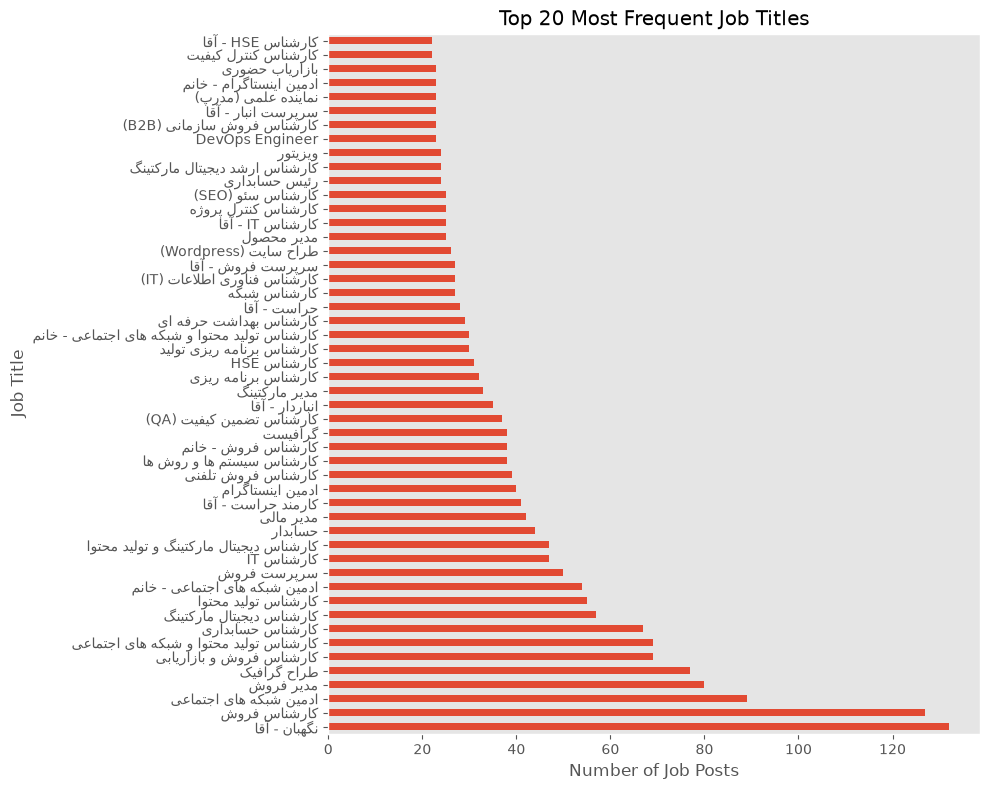

In [10]:
title_counts = df["title"].value_counts()[:50]
title_counts.head(50).plot(kind="barh", figsize=(10,8))
plt.title("Top 20 Most Frequent Job Titles"); plt.grid()
plt.xlabel("Number of Job Posts"); plt.ylabel("Job Title")
plt.tight_layout(); plt.show()

In [11]:
# How concentrated is the job market?
title_distribution = (df["title"].value_counts(normalize=True).mul(100))
top10_share = title_distribution.head(10).sum()
top20_share = title_distribution.head(20).sum()
top50_share = title_distribution.head(50).sum()
print(f"Top 10 titles account for {top10_share:.2f}% of all job postings")
print(f"Top 20 titles account for {top20_share:.2f}% of all job postings")
print(f"Top 50 titles account for {top50_share:.2f}% of all job postings")

Top 10 titles account for 6.83% of all job postings
Top 20 titles account for 10.50% of all job postings
Top 50 titles account for 17.33% of all job postings


## Job Categories
Individual job titles can vary significantly across companies, making direct comparisons difficult.
To obtain a broader view of the labor market, this section analyzes standardized job categories. This helps identify which professional domains receive the highest hiring demand.

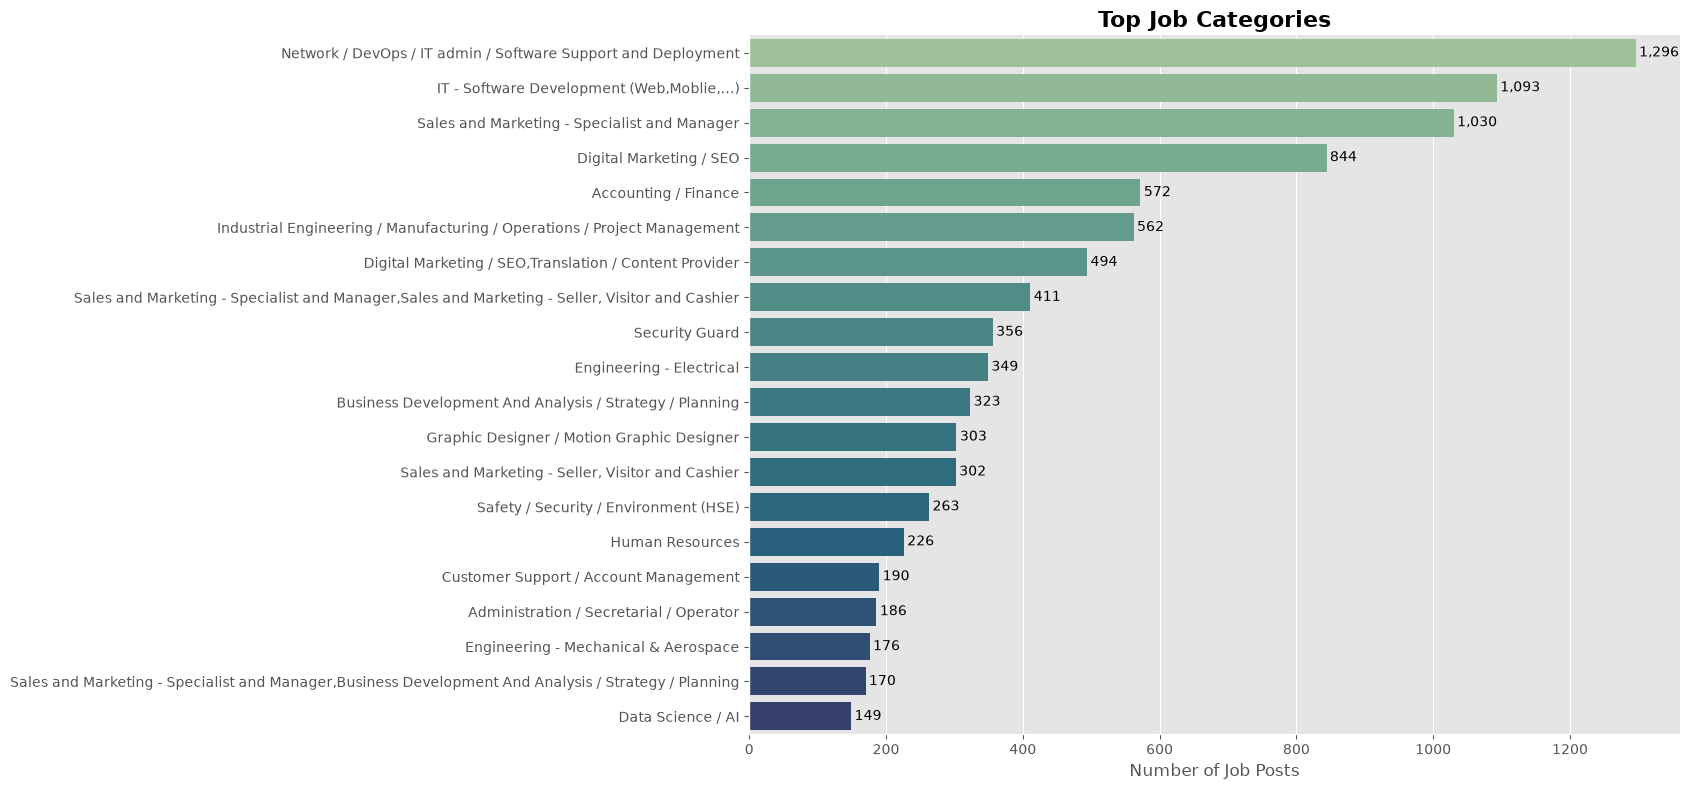

In [12]:
category_counts = (df["category"].fillna("Unknown").value_counts())
plt.figure(figsize=(17, 8))
ax = sns.barplot(x=category_counts[:20].values, y=category_counts[:20].index, hue=category_counts[:20].index, legend=False, palette="crest")
plt.title("Top Job Categories", fontsize=16, weight="bold")
plt.xlabel("Number of Job Posts")
plt.ylabel("")
for i, value in enumerate(category_counts.head(20).values):
    ax.text(value + 5, i, f"{value:,}", va="center")
sns.despine()
plt.tight_layout(); plt.show()

In [13]:
category_share = (df["category"].fillna("Unknown").value_counts(normalize=True).mul(100))
print(f"Top 5 categories represent" f"{category_share.head(5).sum():.2f}% of all jobs.")
print(f"Top 10 categories represent" f"{category_share.head(10).sum():.2f}% of all jobs.")

Top 5 categories represent40.17% of all jobs.
Top 10 categories represent58.21% of all jobs.


## Industry Analysis

This section explores the distribution of job postings across different industries to identify which sectors contribute the most to hiring activity.

In [14]:
df["industries"].head()

0                                                   Transportation / Logistics
1                   Internet Provider / E-commerce / Online Services,Insurance
2    IT / Software / Hardware,Internet Provider / E-commerce / Online Services
3                                                                    Insurance
4    IT / Software / Hardware,Internet Provider / E-commerce / Online Services
Name: industries, dtype: str

In [15]:
industry = (df["industries"].fillna("Unknown").str.split(",").explode().str.strip())
industry.head()

0                          Transportation / Logistics
1    Internet Provider / E-commerce / Online Services
1                                           Insurance
2                            IT / Software / Hardware
2    Internet Provider / E-commerce / Online Services
Name: industries, dtype: str

In [16]:
industry_counts = (industry.value_counts())
industry_counts[:20]

industries
Manufacturing & Production                               2729
IT / Software / Hardware                                 2577
Internet Provider / E-commerce / Online Services         1703
Trading / International Affairs                          1316
Consumer Goods / FMCG                                     977
Engineering Services / Technical Services & Solutions     936
Retail / Shopping center / Store                          775
Finance / Investment                                      628
Automotive                                                625
Oil & Gas / Petrochemical                                 484
Pharmaceutical                                            456
Education / Research                                      437
Construction / Building Materials & Equipment             434
Consumer Electonics / Home Appliances                     414
Marketing / Advertising                                   399
Banking                                                   3

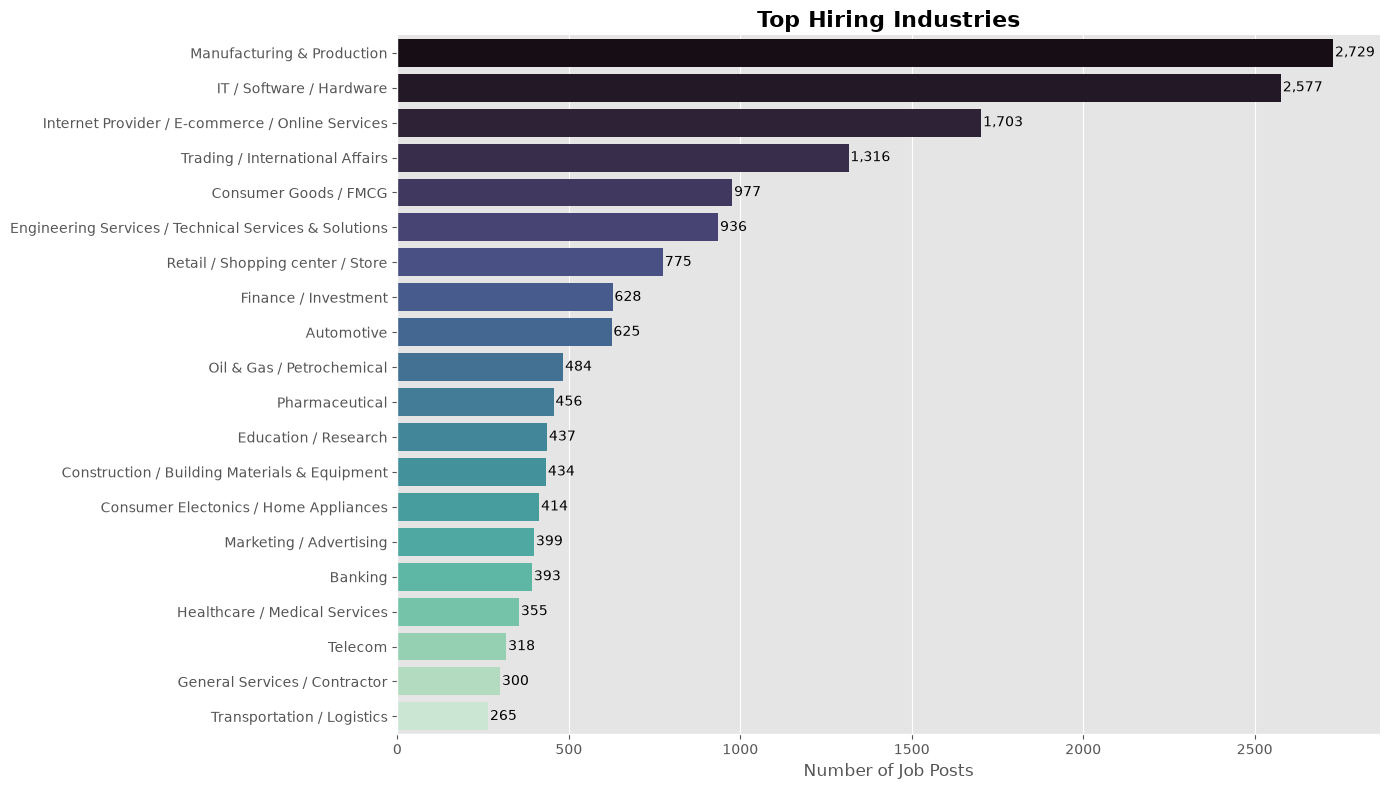

In [17]:
plt.figure(figsize=(14,8))
ax = sns.barplot(x=industry_counts[:20].values, y=industry_counts[:20].index, hue=industry_counts[:20].index, legend=False, palette="mako")
plt.title("Top Hiring Industries", fontsize=16, weight="bold")
plt.xlabel("Number of Job Posts")
plt.ylabel("")
for i, value in enumerate(industry_counts[:20].values):
    ax.text(value + 5, i, f"{value:,}", va="center")
sns.despine(); plt.tight_layout(); plt.show()

In [18]:
industry_share = (industry.value_counts(normalize=True).mul(100).round(2))
industry_share[:15]

industries
Manufacturing & Production                               14.08
IT / Software / Hardware                                 13.29
Internet Provider / E-commerce / Online Services          8.79
Trading / International Affairs                           6.79
Consumer Goods / FMCG                                     5.04
Engineering Services / Technical Services & Solutions     4.83
Retail / Shopping center / Store                          4.00
Finance / Investment                                      3.24
Automotive                                                3.22
Oil & Gas / Petrochemical                                 2.50
Pharmaceutical                                            2.35
Education / Research                                      2.25
Construction / Building Materials & Equipment             2.24
Consumer Electonics / Home Appliances                     2.14
Marketing / Advertising                                   2.06
Name: proportion, dtype: float64

In [19]:
print(f"Top 5 industries account for {industry_share.head(5).sum():.2f}% of all industry mentions.")
print(f"Top 10 industries account for {industry_share.head(10).sum():.2f}% of all industry mentions.")

Top 5 industries account for 47.99% of all industry mentions.
Top 10 industries account for 65.78% of all industry mentions.


## Work Type Analysis
Employment type is one of the most important characteristics of a job market.
This analysis examines the distribution of work arrangements to understand whether employers primarily seek full-time employees or offer more flexible work options such as part-time, project-based, contract, or internship positions.

In [20]:
df["work_type"].value_counts(dropna=False)

work_type
Full Time                 10548
Full Time Or Part Time      685
Part Time                   423
Project - based             381
Name: count, dtype: int64

In [21]:
work_type_dist = (df["work_type"].fillna("Unknown").value_counts().rename_axis("Work Type").reset_index(name="Count"))
work_type_dist["Percentage"] = (work_type_dist["Count"] / work_type_dist["Count"].sum() * 100).round(2)
work_type_dist
# The Iranian job market is heavily dominated by full-time employment opportunities, indicating that employers
# generally prioritize long-term workforce recruitment over flexible work arrangements. Project-based and internship
# positions represent only a small fraction of the market, suggesting limited entry points for students and freelancers.

,Work Type,Count,Percentage
0,Full Time,10548,87.63
1,Full Time Or Part Time,685,5.69
2,Part Time,423,3.51
3,Project - based,381,3.17


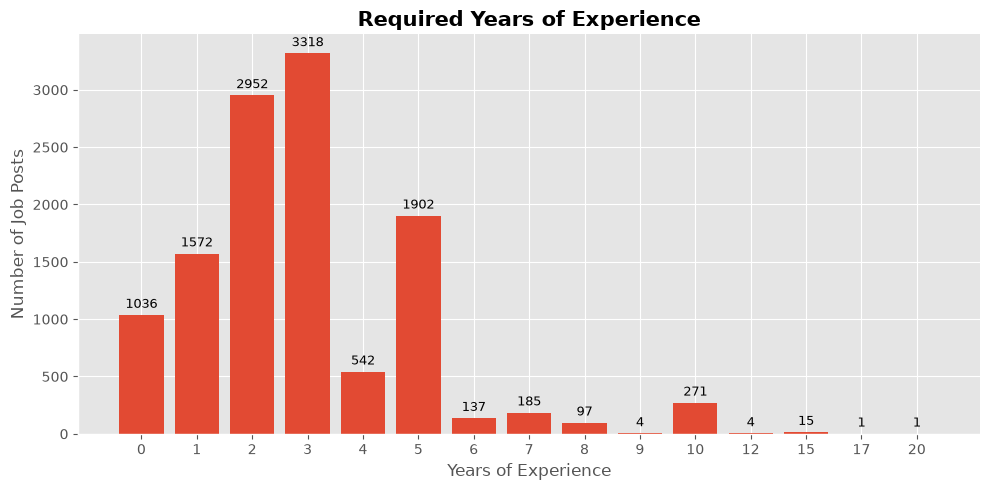

In [22]:
experience_dist = (df["experience_years"].value_counts().sort_index())
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(experience_dist.index.astype(str), experience_dist.values)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Required Years of Experience", fontsize=15, weight="bold")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Number of Job Posts")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

In [23]:
experience_group = pd.cut(
    df["experience_years"],
    bins=[-1,0,2,5,100],
    labels=[
        "No Experience",
        "Junior (1–2)",
        "Mid-Level (3–5)",
        "Senior (6+)"
    ]
)
experience_group.value_counts()

experience_years
Mid-Level (3–5)    5762
Junior (1–2)       4524
No Experience      1036
Senior (6+)         715
Name: count, dtype: int64

# **Company Landscape**

### Is the Iranian job market dominated by a small number of companies, or is hiring distributed across many employers?

In [24]:
company_stats = pd.Series({
    "Total Companies": df["company"].nunique(),
    "Total Job Posts": len(df),
    "Average Jobs per Company": round(len(df) / df["company"].nunique(), 2)
})
company_stats.to_frame("Value")

,Value
Total Companies,5886.00
Total Job Posts,12037.00
Average Jobs per Company,2.05


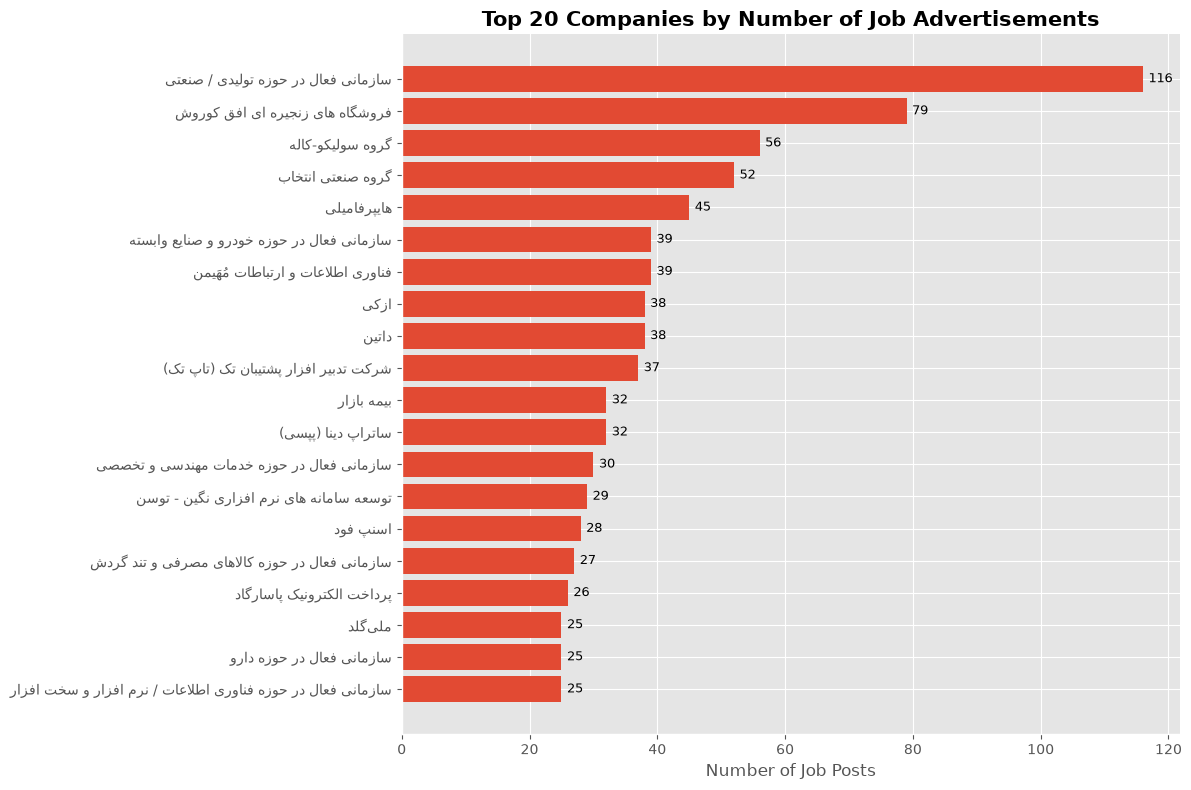

In [25]:
top_companies = (df["company"].fillna("Unknown").value_counts()[:20].sort_values())
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(top_companies.index, top_companies.values)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title("Top 20 Companies by Number of Job Advertisements", fontsize=15, fontweight="bold")
ax.set_xlabel("Number of Job Posts")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [26]:
top10_share = (df["company"].value_counts()[:10].sum() / len(df) * 100)
print(f"Top 10 companies account for {top10_share:.2f}% of all job advertisements.")

Top 10 companies account for 4.48% of all job advertisements.


# **Geographic Landscape**

### How geographically concentrated is the Iranian job market?

In [27]:
province_dist = (df["province"].fillna("Unknown").value_counts().rename_axis("Province").reset_index(name="Job Posts"))
province_dist["Share (%)"] = (province_dist["Job Posts"] / province_dist["Job Posts"].sum() * 100).round(2)
province_dist[:15]

,Province,Job Posts,Share (%)
0,تهران,7891,65.56
1,اصفهان,682,5.67
2,البرز,566,4.70
3,خراسان رضوی,551,4.58
4,مازندران,318,2.64
5,فارس,235,1.95
6,قم,205,1.70
7,گیلان,161,1.34
8,خوزستان,155,1.29
9,کرمان,151,1.25


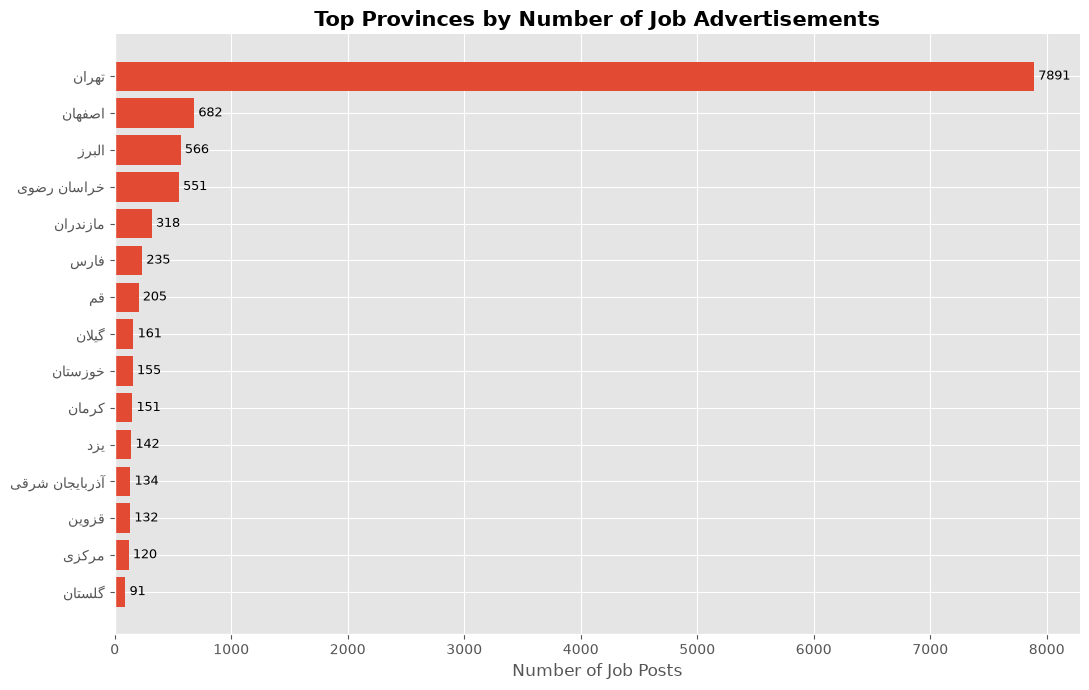

In [28]:
top_provinces = province_dist[:15].sort_values("Job Posts")
fig, ax = plt.subplots(figsize=(11,7))
bars = ax.barh(top_provinces["Province"], top_provinces["Job Posts"])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title( "Top Provinces by Number of Job Advertisements", fontsize=15, fontweight="bold")
ax.set_xlabel("Number of Job Posts")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [29]:
top5_share = (province_dist.head(5)["Job Posts"].sum() / len(df) * 100)
print(f"Top 5 provinces account for {top5_share:.2f}% of all job advertisements.")

Top 5 provinces account for 83.14% of all job advertisements.


In [30]:
city_dist = (df["city"].fillna("Unknown").value_counts()[:20])
city_dist

city
تهران      7195
اصفهان      555
مشهد        514
کرج         327
شیراز       222
قم          197
یزد         124
رشت         119
تبریز       118
پردیس       113
کرمان       110
اهواز       101
ساری         75
قزوین        71
شهر قدس      69
بابل         66
آمل          59
پاکدشت       57
ساوه         55
گرگان        54
Name: count, dtype: int64

In [31]:
remote_dist = (df["remote"].fillna(False).value_counts().rename_axis("Remote").reset_index(name="Job Posts"))
remote_dist["Percentage"] = ( remote_dist["Job Posts"] / remote_dist["Job Posts"].sum() * 100).round(2)
remote_dist

,Remote,Job Posts,Percentage
0,False,11331,94.13
1,True,706,5.87


In [32]:
province_remote = (df.groupby("province")["remote"].mean().mul(100).sort_values(ascending=False))
province_remote[:20]

province
خراسان جنوبی          41.666667
چهارمحال و بختیاری    22.222222
اردبیل                18.181818
کرمانشاه               9.090909
فارس                   8.085106
مازندران               7.861635
همدان                  7.692308
اصفهان                 7.624633
خراسان رضوی            7.622505
خوزستان                7.096774
آذربایجان شرقی         6.716418
گلستان                 6.593407
کرمان                  5.960265
تهران                  5.601318
لرستان                 5.000000
گیلان                  4.968944
قم                     4.878049
یزد                    4.225352
بوشهر                  3.636364
سمنان                  3.571429
Name: remote, dtype: float64

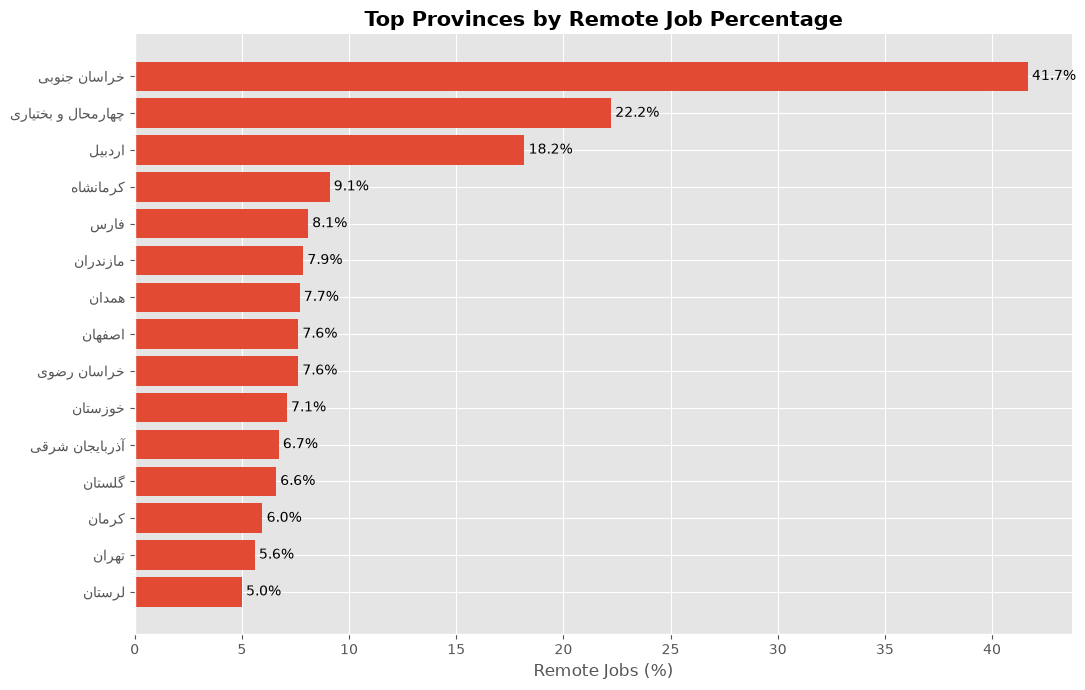

In [33]:
fig, ax = plt.subplots(figsize=(11,7))
bars = ax.barh(province_remote.head(15).sort_values().index, province_remote.head(15).sort_values().values)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Top Provinces by Remote Job Percentage", fontsize=15, weight="bold")
ax.set_xlabel("Remote Jobs (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [34]:
df.groupby("province").agg(total_jobs=("job_id","count"), remote_jobs=("remote","sum"))

,total_jobs,remote_jobs
province,,
آذربایجان شرقی,134,9
آذربایجان غربی,32,1
اردبیل,33,6
اصفهان,682,52
البرز,566,17
ایلام,9,0
بوشهر,55,2
تهران,7891,442
خراسان جنوبی,12,5


In [35]:
remote_city = (df[df["remote"] == True]["city"].value_counts()[:15])
onsite_city = (df[df["remote"] == False]["city"].value_counts()[:15])
display(remote_city)
display(onsite_city)

city
تهران        428
اصفهان        42
مشهد          42
شیراز         18
خارج کشور     15
کرج           15
ساری          14
قم            10
تبریز          8
کرمان          7
اهواز          7
اردبیل         6
رشت            6
کاشان          5
بیرجند         5
Name: count, dtype: int64

city
تهران      6767
اصفهان      513
مشهد        472
کرج         312
شیراز       204
قم          187
یزد         119
رشت         113
پردیس       110
تبریز       110
کرمان       103
اهواز        94
شهر قدس      68
قزوین        68
بابل         63
Name: count, dtype: int64

# **Skill Market Analysis**

## Skill Coverage
How many job postings explicitly mention technical skills?

In [36]:
skill_available = (df["software"].notna().mean() * 100)
print(f"{skill_available:.2f}% of job advertisements specify software requirements.")

coverage = pd.DataFrame({"Has Skills": [df["software"].notna().sum(), df["software"].isna().sum()]}, index=["Yes","No"])
coverage

70.86% of job advertisements specify software requirements.


,Has Skills
Yes,8530
No,3507


## Most Demanded Skills

In [37]:
skills = (df["software"].dropna().str.split(",").explode().str.strip())
skills.head()

0             Python
0    Oracle Database
0                GIT
1             Python
1         PostgreSql
Name: software, dtype: str

In [38]:
top_skills = (skills.value_counts().head(25))
top_skills

software
Microsoft Excel          4252
Microsoft Word           2910
Adobe Photoshop           868
Microsoft Powerpoint      742
GIT                       665
Sql Server                664
Python                    523
PowerBI                   518
Linux                     503
Adobe Premiere            498
Google Analytics          480
Docker                    438
Adobe Illustrator         407
Wordpress                 397
Rest API                  385
Microsoft Outlook         381
JavaScript                371
After Effects             367
Windows Server            355
Google Search Console     347
راهکاران                  332
Html & CSS                319
AutoCad                   312
Microsoft Project         289
Active Directory          266
Name: count, dtype: int64

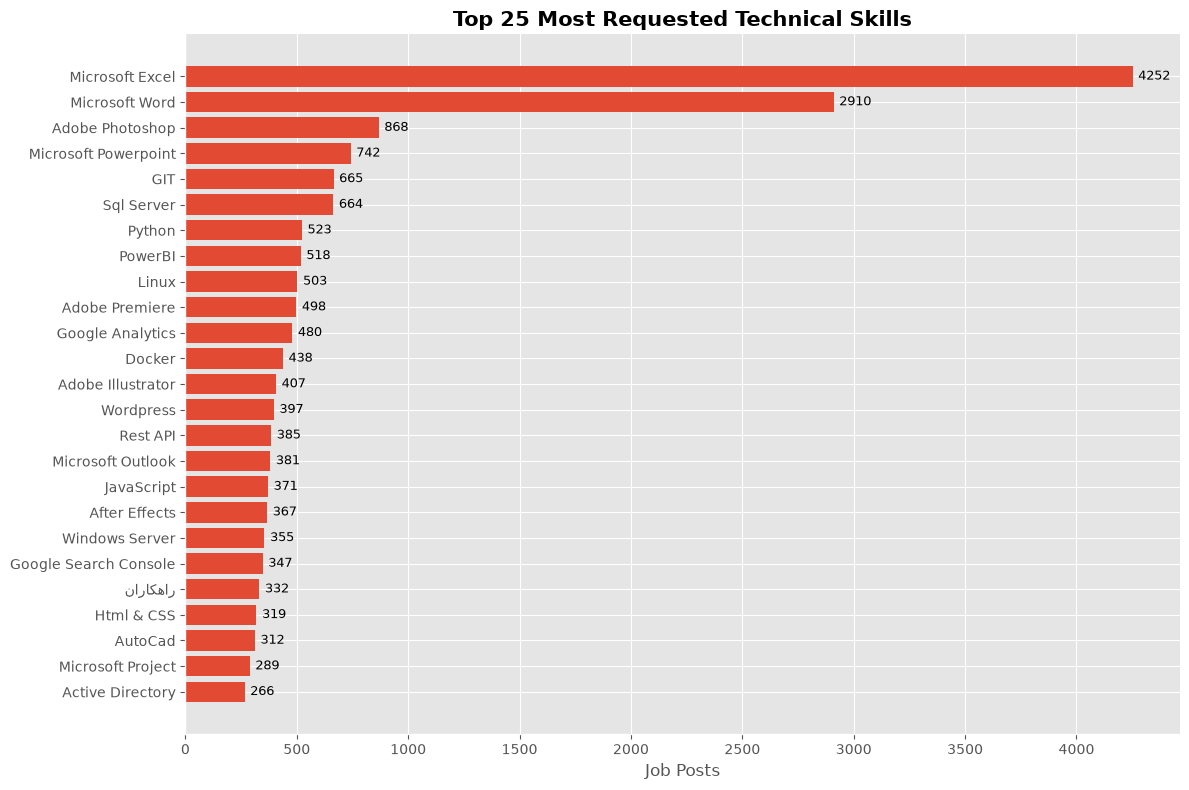

In [39]:
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(top_skills.sort_values().index, top_skills.sort_values().values)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title("Top 25 Most Requested Technical Skills", fontsize=15, fontweight="bold")
ax.set_xlabel("Job Posts")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## Average Skill Count

In [40]:
skill_count = (df["software"].fillna("").str.split(",").apply(lambda x: len([i for i in x if i.strip()])))
skill_count.describe()

count    12037.000000
mean         2.316275
std          2.256502
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max         20.000000
Name: software, dtype: float64

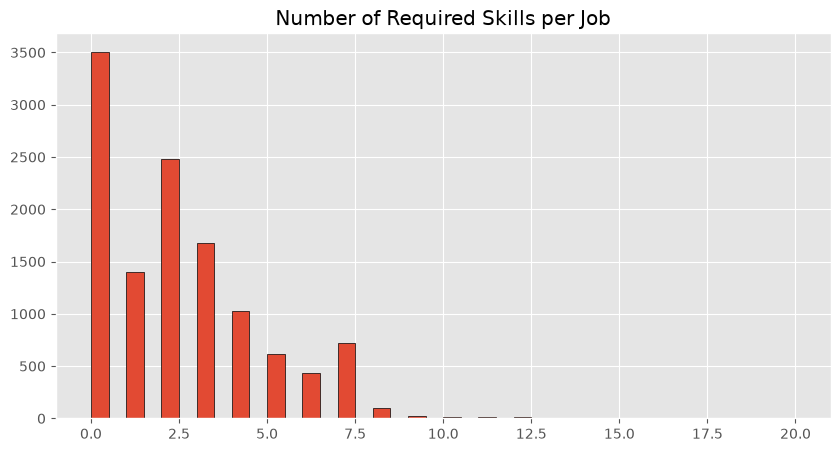

In [41]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(skill_count, bins=40, edgecolor="black")
ax.set_title("Number of Required Skills per Job")
plt.show()

## Skill Co-occurrence Analysis
Which technical skills are commonly required together in the Iranian job market?

In [42]:
df_it = df.copy()

# 1. Define IT / Software keywords
it_keywords = [
    # Software Engineering
    "developer",
    "programmer",
    "software engineer",
    "software developer",
    "backend",
    "frontend",
    "full stack",

    # Programming Languages
    "python",
    "java",
    "javascript",
    "typescript",
    "php",
    "kotlin",
    "swift",
    "c#",
    ".net",

    # Frameworks
    "django",
    "flask",
    "fastapi",
    "spring",
    "react",
    "angular",
    "vue",
    "node",

    # Data / AI
    "data",
    "machine learning",
    "artificial intelligence",
    "deep learning",

    # DevOps
    "devops",
    "docker",
    "kubernetes",
    "cloud",
    "linux",

    # Database
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "oracle",

    # Persian
    "برنامه نویس",
    "توسعه دهنده",
    "مهندس نرم افزار",
    "برنامه نویسی",
    "بک اند",
    "فرانت اند",
]

In [43]:
pattern = "|".join(it_keywords)

df_it = df_it[
    df_it["keyword"].astype(str).str.lower().str.contains(pattern, na=False)
    |
    df_it["title"].astype(str).str.lower().str.contains(pattern, na=False)
]

print("Total jobs:", len(df))
print("IT jobs:", len(df_it))

Total jobs: 12037
IT jobs: 8061


In [44]:
skills_df = (df_it[["job_id", "software"]].dropna().copy())
print(len(skills_df))

6467


In [45]:
skills_df["software"] = skills_df["software"].apply(
    lambda x: [
        skill.strip().lower()
        for skill in x.split(",")
        if skill.strip()
    ]
)

In [46]:
technical_skills = {
    "python",
    "java",
    "javascript",
    "typescript",
    "php",
    "c#",
    ".net",

    "django",
    "flask",
    "fastapi",
    "spring",
    "react",
    "angular",
    "vue",
    "node",

    "docker",
    "kubernetes",
    "linux",
    "git",

    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "oracle",

    "redis",
    "rabbitmq",

    "rest api",
    "unit testing",

    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",

    "spark",
    "airflow"
}

In [47]:
skills_df["software"] = skills_df["software"].apply(lambda skills: [skill for skill in skills if skill in technical_skills])

In [48]:
skills_df = skills_df[skills_df["software"].apply(len) > 0]

In [49]:
from itertools import combinations
from collections import Counter


skill_pairs = []

for skills in skills_df["software"]:

    skills = set(skills)

    if len(skills) < 2:
        continue

    skill_pairs.extend(
        combinations(sorted(skills), 2)
    )


pair_df = (
    pd.DataFrame(
        Counter(skill_pairs).items(),
        columns=["Skill Pair", "Frequency"]
    )
    .sort_values(
        "Frequency",
        ascending=False
    )
)


pair_df.head(20)

,Skill Pair,Frequency
43,"(docker, git)",232
23,"(git, rest api)",230
71,"(git, javascript)",200
54,"(docker, linux)",162
3,"(docker, python)",149
1,"(docker, kubernetes)",147
0,"(git, python)",143
76,"(git, react)",139
126,"(git, typescript)",138
27,"(linux, python)",133


## Skill Network Graph


In [50]:
import networkx as nx

G = nx.Graph()

for _, row in pair_df.head(50).iterrows():
    skill1, skill2 = row["Skill Pair"]
    G.add_edge(skill1, skill2, weight=row["Frequency"])

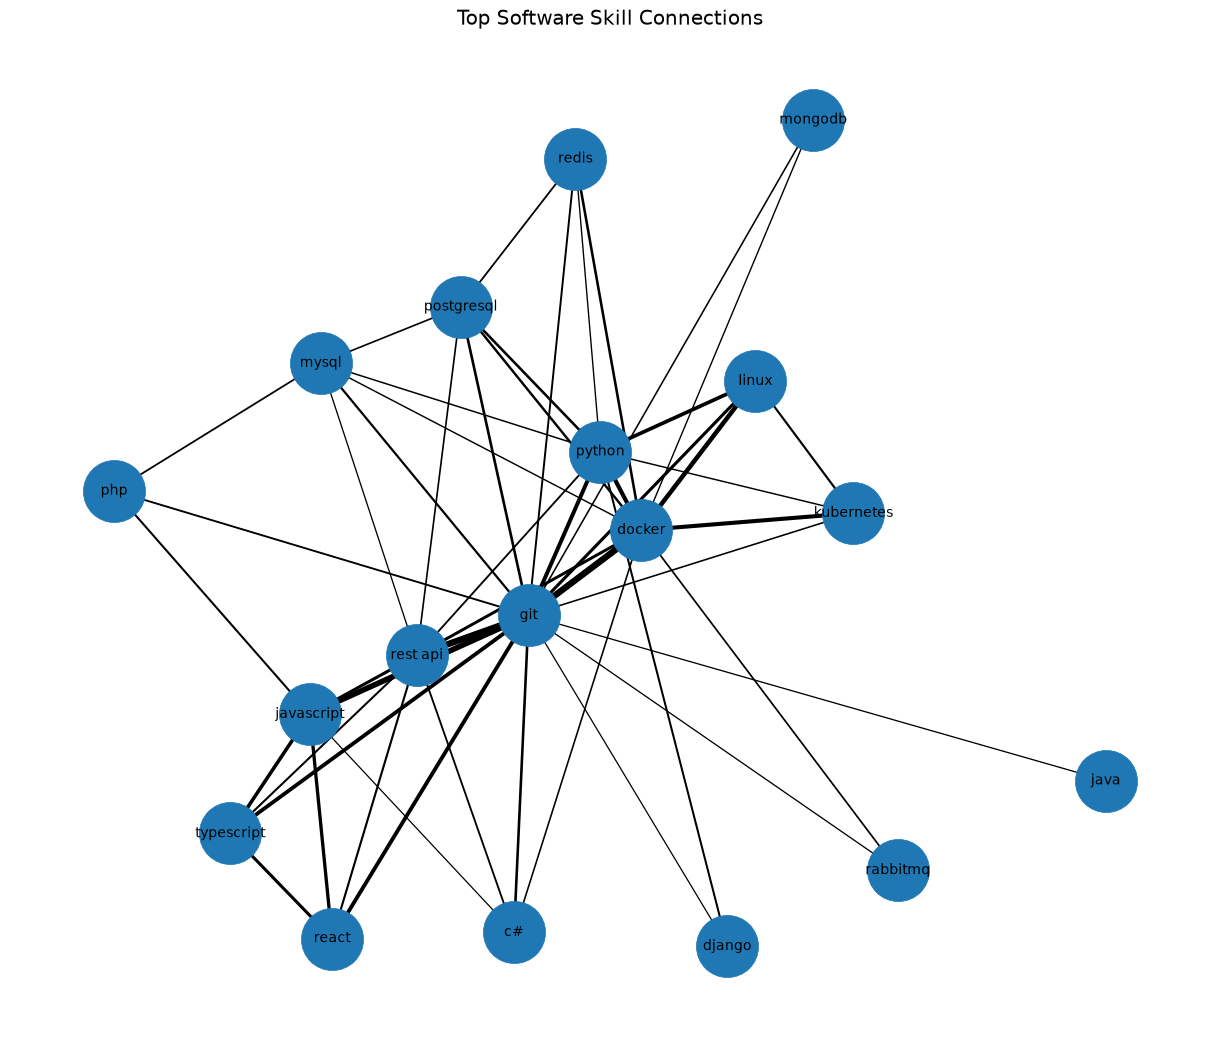

In [51]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.8, seed=42)

nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10, width=[G[u][v]["weight"] / 50 for u, v in G.edges()])

plt.title("Top Software Skill Connections"); plt.show()

In [52]:
skills_df = (df[["job_id", "software"]].dropna().copy())

skills_df["skill"] = (skills_df["software"].str.split(","))

skills_df = (skills_df.explode("skill"))

skills_df["skill"] = (skills_df["skill"].str.strip())

skills_df.head()

,job_id,software,skill
0,1396130,"Python,Oracle Database,GIT",Python
0,1396130,"Python,Oracle Database,GIT",Oracle Database
0,1396130,"Python,Oracle Database,GIT",GIT
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",Python
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",PostgreSql


In [53]:
skills_df["skill_clean"] = (skills_df["skill"].str.lower())
skills_df.head()

,job_id,software,skill,skill_clean
0,1396130,"Python,Oracle Database,GIT",Python,python
0,1396130,"Python,Oracle Database,GIT",Oracle Database,oracle database
0,1396130,"Python,Oracle Database,GIT",GIT,git
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",Python,python
1,1401623,"Python,PostgreSql,Prometheus,Gerafana,Docker,Redis,Kubernetes",PostgreSql,postgresql


In [54]:
skills_df = (skills_df[skills_df["skill_clean"] != ""])
skills_df.shape

(27881, 4)

In [55]:
skill_per_job = (skills_df.groupby("job_id")["skill_clean"].count())
skill_per_job.describe()

count    8530.000000
mean        3.268581
std         2.018024
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: skill_clean, dtype: float64

In [56]:
from itertools import combinations


skill_pairs = []


for skills in (skills_df.groupby("job_id")["skill_clean"]):
    job_skills = sorted(set(skills[1]))
    if len(job_skills) < 2:
        continue
    pairs = combinations(job_skills, 2)
    skill_pairs.extend(pairs)

pairs_df = pd.DataFrame(skill_pairs, columns=["skill_1", "skill_2"])
pairs_df.head()

,skill_1,skill_2
0,docker,gitlab
1,docker,kubernetes
2,docker,linux
3,docker,prometheus
4,gitlab,kubernetes


In [57]:
pair_frequency = (pairs_df.value_counts().reset_index())
pair_frequency.columns = ["skill_1", "skill_2", "frequency"]
pair_frequency.head(20)

,skill_1,skill_2,frequency
0,microsoft excel,microsoft word,2890
1,microsoft excel,microsoft powerpoint,725
2,microsoft powerpoint,microsoft word,649
3,microsoft excel,powerbi,408
4,adobe photoshop,adobe premiere,404
5,adobe illustrator,adobe photoshop,391
6,microsoft excel,microsoft outlook,371
7,microsoft outlook,microsoft word,340
8,adobe premiere,after effects,324
9,google analytics,google search console,315


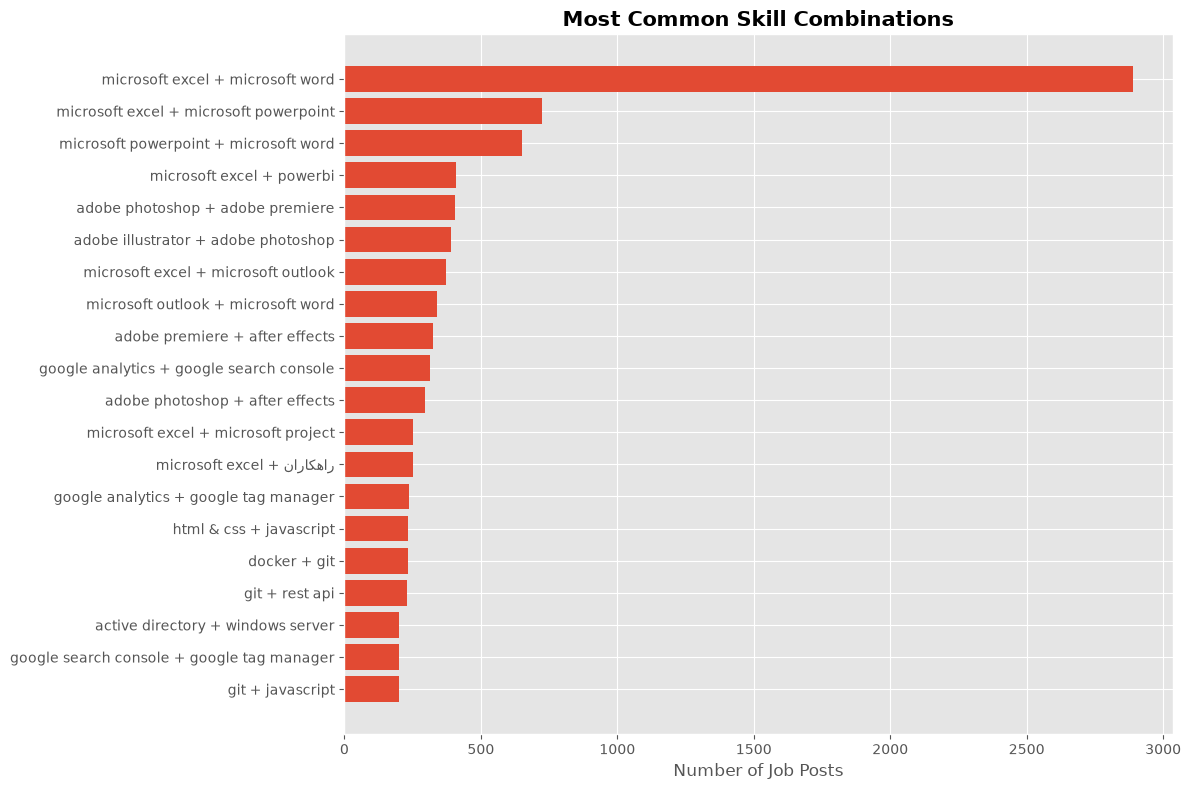

In [58]:
top_pairs = (pair_frequency[:20].copy())
top_pairs["pair"] = (top_pairs["skill_1"] + " + " + top_pairs["skill_2"])
top_pairs = (top_pairs.sort_values("frequency"))

plt.figure(figsize=(12,8))
plt.barh(top_pairs["pair"], top_pairs["frequency"])
plt.title("Most Common Skill Combinations", fontsize=15, weight="bold")
plt.xlabel("Number of Job Posts")
plt.tight_layout()
plt.show()

# **Salary Analysis**

In [ ]:
# Salary Coverage
df["salary_visible"].value_counts(normalize=True)

salary_visible
False    0.660796
True     0.339204
Name: proportion, dtype: float64

In [63]:
#Salary Distribution
df[["salary_min","salary_max"]].describe()

,salary_min,salary_max
count,4083.000000,4083.000000
mean,37.957384,52.469753
std,21.876399,30.006634
min,3.000000,4.000000
25%,25.000000,35.000000
50%,30.000000,45.000000
75%,45.000000,60.000000
max,300.000000,400.000000


In [64]:
df.groupby("experience_years")[["salary_min","salary_max"]].median()

,salary_min,salary_max
experience_years,,
0,24.0,35.0
1,25.0,35.0
2,30.0,40.0
3,35.0,45.0
4,40.0,50.0
5,45.0,60.0
6,53.5,70.0
7,60.0,72.0
8,67.0,100.0


In [65]:
salary_category = (df.groupby("category")["salary_max"].median().sort_values(ascending=False))
salary_category.head(20)

category
Purchasing / Procurement,CEO / Business Head / Factory Manager                                                                            200.0
Sales and Marketing - Specialist and Manager,CEO / Business Head / Factory Manager                                                        200.0
Business Development And Analysis / Strategy / Planning,CEO / Business Head / Factory Manager                                             150.0
CEO / Business Head / Factory Manager                                                                                                     150.0
Sales and Marketing - Specialist and Manager,Digital Marketing / SEO,Business Development And Analysis / Strategy / Planning              150.0
Industrial Engineering / Manufacturing / Operations / Project Management,CEO / Business Head / Factory Manager                            150.0
CEO / Business Head / Factory Manager,Mining Engineering & Geology                                                             

In [66]:
df.groupby("remote")[["salary_min","salary_max"]].median()

,salary_min,salary_max
remote,,
False,32.0,45.0
True,30.0,40.0


In [69]:
salary_df = df[df["salary_min"].notna()].copy()
print(f"Salary available jobs: {len(salary_df)} / {len(df)} ({len(salary_df) / len(df) * 100:.2f}%)")

Salary available jobs: 4083 / 12037 (33.92%)


In [70]:
salary_df[["salary_min", "salary_max"]].median()

salary_min    30.0
salary_max    45.0
dtype: float64

In [71]:
salary_df.sort_values("salary_max", ascending=False)[["title", "company", "salary_min", "salary_max"]][:20]

,title,company,salary_min,salary_max
7761,Head of Growth & Marketing - خانم,مرکز بیزینس کوچینگ ایران,267.0,400.0
8464,مشاور فروش املاک,املاک غلامی,267.0,400.0
248,Senior Data Manager,یوزرآوا,300.0,350.0
9757,Senior Marketing Manager,یوزرآوا,280.0,300.0
6508,مدیر فروش و بازاریابی - آقا,پیشگامان انرژی نورا تِک,180.0,250.0
855,مدیر ارشد فناوری,اهلال سان,200.0,250.0
3267,مدیر مالی,سازمانی فعال در حوزه دارو,200.0,250.0
3298,مدیر مالی,سازمانی فعال در حوزه فناوری اطلاعات / نرم افزار و سخت افزار,200.0,250.0
11034,مدیر فروش,شرکت سرام پخش سورن,200.0,250.0
4433,Senior SEO Manager,یوزرآوا,200.0,230.0


In [74]:
salary_df["salary_avg"] = (salary_df["salary_min"] + salary_df["salary_max"]) / 2
salary_df["salary_avg"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01     17.41
0.05     22.50
0.25     30.00
0.50     37.50
0.75     52.50
0.95     90.00
0.99    142.54
Name: salary_avg, dtype: float64

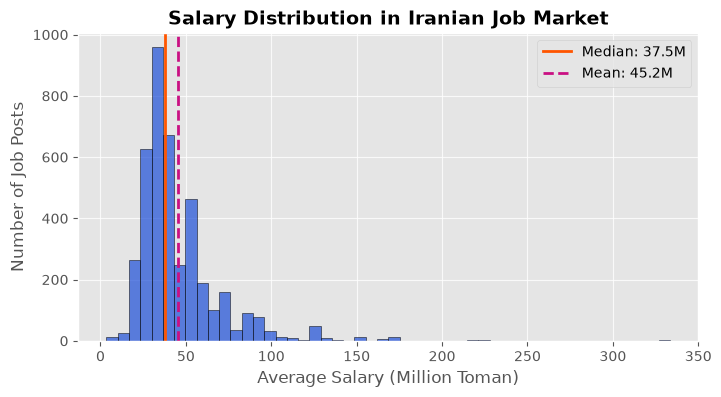

In [126]:
plt.figure(figsize=(8,4))
plt.hist(salary_df["salary_avg"], bins=50, edgecolor="black", color="#1D4ED8", alpha=0.7)
plt.axvline(salary_df["salary_avg"].median(),color="#FF5500" , linestyle="-", linewidth=2, label=f"Median: {salary_df['salary_avg'].median():.1f}M")
plt.axvline(salary_df["salary_avg"].mean(),color="#CA1083", linestyle="--", linewidth=2, label=f"Mean: {salary_df['salary_avg'].mean():.1f}M")
plt.title("Salary Distribution in Iranian Job Market", fontsize=14, fontweight="bold")
plt.xlabel("Average Salary (Million Toman)")
plt.ylabel("Number of Job Posts")
plt.legend()
plt.grid(alpha=0.8)
plt.show()

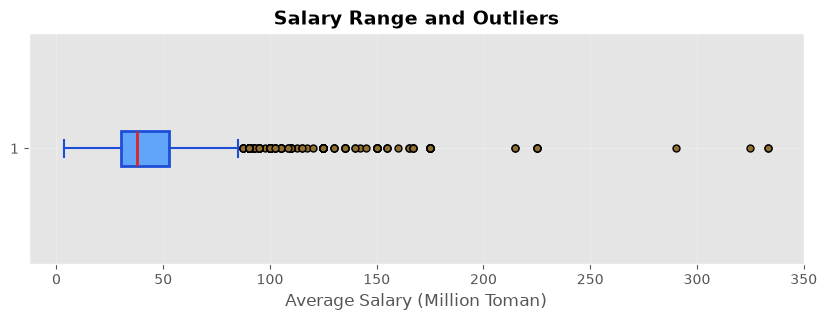

In [128]:
plt.figure(figsize=(10,3))

plt.boxplot(
    salary_df["salary_avg"],
    vert=False,
    patch_artist=True,

    boxprops=dict(
        facecolor="#60A5FA",
        color="#1D4ED8",
        linewidth=2
    ),

    medianprops=dict(
        color="#DC2626",
        linewidth=2
    ),

    whiskerprops=dict(
        color="#1D4ED8",
        linewidth=1.5
    ),

    capprops=dict(
        color="#1D4ED8",
        linewidth=1.5
    ),

    flierprops=dict(
        marker="o",
        markerfacecolor="#916E31",
        markeredgecolor="#000000",
        markersize=5,
        linestyle="none"
    )
)

plt.title("Salary Range and Outliers", fontsize=14, fontweight="bold")
plt.xlabel("Average Salary (Million Toman)")
plt.grid(alpha=0.25); plt.show()

### Salary vs Experience Analysis

In [130]:
salary_exp_df = salary_df[salary_df["experience_years"].notna()].copy()
experience_distribution = (salary_exp_df["experience_years"].value_counts().sort_index())
experience_distribution

experience_years
0      401
1      569
2     1068
3     1082
4      186
5      564
6       38
7       41
8       37
10      87
12       3
15       6
20       1
Name: count, dtype: int64

In [131]:
salary_by_experience = (salary_exp_df
.groupby("experience_years")
    ["salary_avg"]
    .agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)
salary_by_experience

,experience_years,count,median_salary,mean_salary
0,0,401,29.50,32.239401
1,1,569,30.00,34.015817
2,2,1068,35.00,38.650749
3,3,1082,40.00,44.546211
4,4,186,45.00,52.586022
5,5,564,55.00,60.939716
6,6,38,61.25,71.723684
7,7,41,65.00,86.000000
8,8,37,83.50,85.000000
9,10,87,90.00,95.040230


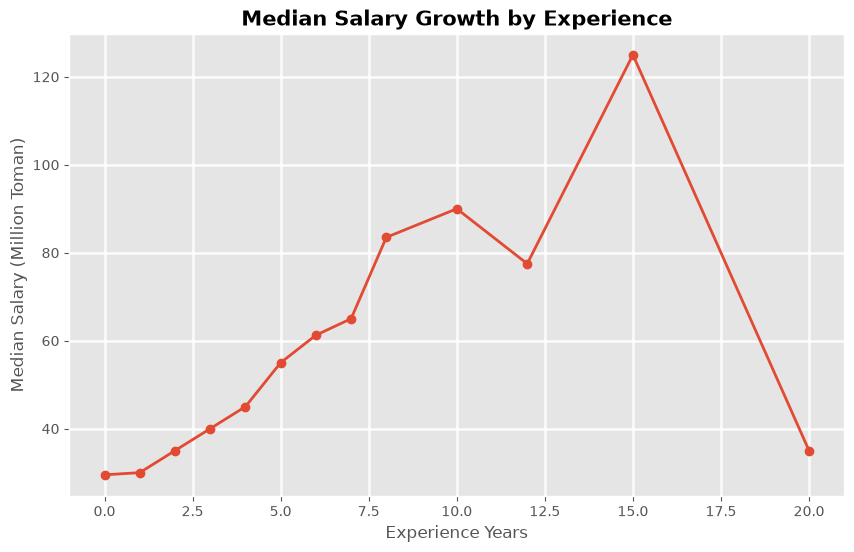

In [142]:
plt.figure(figsize=(10,6))
plt.plot(salary_by_experience["experience_years"], salary_by_experience["median_salary"], marker="o", linewidth=2, markersize=6)
plt.title("Median Salary Growth by Experience", fontsize=15, fontweight="bold")
plt.xlabel("Experience Years")
plt.ylabel("Median Salary (Million Toman)")
plt.grid(alpha=0.8, linestyle="-", linewidth=2); plt.show()

In [148]:
salary_by_experience

,experience_years,median_salary,q1_salary,q3_salary
0,0,29.50,23.500,35.00
1,1,30.00,25.000,40.00
2,2,35.00,29.500,44.00
3,3,40.00,32.500,50.00
4,4,45.00,35.000,60.00
5,5,55.00,42.000,70.00
6,6,61.25,53.125,90.00
7,7,65.00,55.000,95.00
8,8,83.50,67.000,95.00
9,10,90.00,70.000,125.00


In [145]:
def experience_level(years):
    if years <= 1:
        return "Junior"
    elif years <= 3:
        return "Mid-Level"
    elif years <= 5:
        return "Senior"
    else:
        return "Expert"

salary_exp_df["experience_level"] = (salary_exp_df["experience_years"].apply(experience_level))

In [146]:
salary_exp_df.groupby("experience_level")["salary_avg"].agg(["count","median","mean"])

,count,median,mean
experience_level,,,
Expert,213,80.0,87.769953
Junior,970,30.0,33.281443
Mid-Level,2150,37.5,41.617674
Senior,750,50.0,58.868000


### Key Findings

- Experience has a strong positive relationship with salary levels in the Iranian job market.
- The largest salary growth occurs during the transition from junior to senior positions.
- Mid-level candidates represent the largest share of salary-reported positions, indicating strong market demand.
- Expert-level positions receive significantly higher compensation, although they represent a smaller portion of job postings.
- Experience alone does not fully explain salary differences; job category, skills, and location should also be considered.

# **Salary by Job Category Analysis**

### Category Salary Dataset

In [152]:
salary_category_df = salary_df[salary_df["category"].notna()].copy()
category_counts = (salary_category_df["category"].value_counts())
category_counts[:20]

category
Digital Marketing / SEO                                                                           417
Sales and Marketing - Specialist and Manager                                                      352
Network / DevOps / IT admin / Software Support and Deployment                                     324
IT - Software Development (Web,Moblie,…)                                                          310
Digital Marketing / SEO,Translation / Content Provider                                            257
Sales and Marketing - Specialist and Manager,Sales and Marketing - Seller, Visitor and Cashier    219
Accounting / Finance                                                                              210
Industrial Engineering / Manufacturing / Operations / Project Management                          158
Sales and Marketing - Seller, Visitor and Cashier                                                 157
Graphic Designer / Motion Graphic Designer                               

In [153]:
salary_by_category = (salary_category_df.groupby("category")["salary_avg"]
.agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)
salary_by_category

,category,count,median_salary,mean_salary
0,Accounting / Finance,210,42.25,53.569048
1,"Accounting / Finance,Administration / Secretarial / Operator",3,30.00,29.833333
2,"Accounting / Finance,Financial Market Trader and Analyst",2,39.00,39.000000
3,Administration / Secretarial / Operator,79,29.50,29.272152
4,"Administration / Secretarial / Operator,Executive Manager",1,25.00,25.000000
...,...,...,...,...
203,Transport / Logistics / Warehousing,40,40.00,44.650000
204,"Transport / Logistics / Warehousing,Accounting / Finance",1,52.50,52.500000
205,"Transport / Logistics / Warehousing,Administration / Secretarial / Operator",1,34.00,34.000000
206,"Transport / Logistics / Warehousing,Engineering - Civil",1,37.50,37.500000


In [ ]:
salary_by_category_filtered = (salary_by_category[salary_by_category["count"] >= 20].sort_values("median_salary", ascending=False))
salary_by_category_filtered[:20]

,category,count,median_salary,mean_salary
38,Data Science / AI,35,60.00,65.842857
176,"Sales and Marketing - Specialist and Manager,Digital Marketing / SEO",27,52.50,66.444444
60,Engineering - Civil,23,50.00,50.630435
10,Business Development And Analysis / Strategy / Planning,61,50.00,58.524590
101,Industrial Engineering / Manufacturing / Operations / Project Management,158,50.00,53.806962
27,Commercial Affairs / Trading,37,50.00,60.878378
91,"IT - Software Development (Web,Moblie,…)",310,50.00,56.877419
165,Sales and Marketing - Specialist and Manager,352,50.00,57.353693
63,Engineering - Electrical,119,47.50,52.105042
90,Human Resources,52,45.00,50.548077


In [ ]:
it_salary_category = (salary_category_df[salary_category_df["category"].str.contains("IT|Software|Data|Network|DevOps", case=False, na=False)
    ]
    .groupby("category")
    ["salary_avg"]
    .agg(
        count="count",
        median_salary="median"
    )
    .query("count >= 10")
    .sort_values(
        "median_salary",
        ascending=False
    )
)
it_salary_category

,count,median_salary
category,,
Data Science / AI,35,60.00
"Sales and Marketing - Specialist and Manager,Digital Marketing / SEO",27,52.50
"IT - Software Development (Web,Moblie,…)",310,50.00
"Data Science / AI,Business Development And Analysis / Strategy / Planning",17,45.00
Safety / Security / Environment (HSE),48,43.75
Network / DevOps / IT admin / Software Support and Deployment,324,40.00
"Digital Marketing / SEO,IT - Software Development (Web,Moblie,…)",12,38.00
"Sales and Marketing - Specialist and Manager,Sales and Marketing - Seller, Visitor and Cashier",219,35.00
Engineering - Architecture,10,33.75


### Key Findings

- Data Science / AI roles show the highest median salary among analyzed categories, although the number of available positions is relatively limited.
- Software Development provides the strongest balance between salary level and market demand, making it one of the most attractive career paths.
- DevOps and IT Administration roles have high job volume but lower median compensation, suggesting a wide range of skill levels within this category.
- Salary differences across categories highlight the importance of career direction when recommending job paths.

# **Skill Premium Analysis**
Which skills are associated with higher job value and salary levels in the Iranian job market?

In [163]:
salary_skill_df = salary_df[salary_df["software"].notna()].copy()
salary_skill_df["skills"] = (salary_skill_df["software"].str.split(","))
salary_skill_df[["software", "skills"]].head()

,software,skills
6,"Linux,OpenCV,Python,C","[Linux, OpenCV, Python, C]"
7,"Python,Rest API,Django,PostgreSql,Redis,GIT,Linux","[Python, Rest API, Django, PostgreSql, Redis, GIT, Linux]"
13,"Redis,PostgreSql,Python,Docker,GIT,Django","[Redis, PostgreSql, Python, Docker, GIT, Django]"
17,"Python,Rest API,PostgreSql,MongoDB,GIT,Docker,RabbitMQ","[Python, Rest API, PostgreSql, MongoDB, GIT, Docker, RabbitMQ]"
18,"Python,Rest API,Elastic Search,Kubernetes,Django","[Python, Rest API, Elastic Search, Kubernetes, Django]"


In [164]:
skill_salary_df = (salary_skill_df.explode("skills").rename(columns={"skills":"skill"}))
skill_salary_df.shape

(9605, 35)

In [166]:
ignore_skills = [
    "Microsoft Excel",
    "Microsoft Word",
    "Microsoft Powerpoint",
    "Microsoft Outlook"
]

skill_salary_df = skill_salary_df[~skill_salary_df["skill"].isin(ignore_skills)]
skill_salary = (skill_salary_df.groupby("skill")["salary_avg"]
    .agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)
skill_salary

,skill,count,median_salary,mean_salary
0,.Net Core / .Net,43,58.50,59.558140
1,3D Studio Max,12,36.25,38.541667
2,A+,7,47.50,56.428571
3,ADS (Advanced Design Systems),3,50.00,51.666667
4,ARCGIS,6,52.50,55.000000
...,...,...,...,...
275,همکاران سیستم,46,48.00,60.228261
276,ورا نگر,4,40.00,50.625000
277,ویژن,1,40.00,40.000000
278,پیام گستر,8,40.00,56.375000


In [167]:
skill_salary_filtered = (skill_salary[skill_salary["count"] >= 20].sort_values("median_salary", ascending=False))
skill_salary_filtered[:30]

,skill,count,median_salary,mean_salary
192,Redis,50,62.50,66.880000
118,Kubernetes,28,61.25,66.303571
91,Gitlab,26,60.00,68.326923
151,Node.js,44,59.25,66.340909
0,.Net Core / .Net,43,58.50,59.558140
67,Docker,109,57.50,61.784404
174,PostgreSql,64,55.00,59.750000
35,C,26,55.00,60.384615
66,Django,32,52.50,56.625000
5,ASP.Net,25,52.50,49.800000


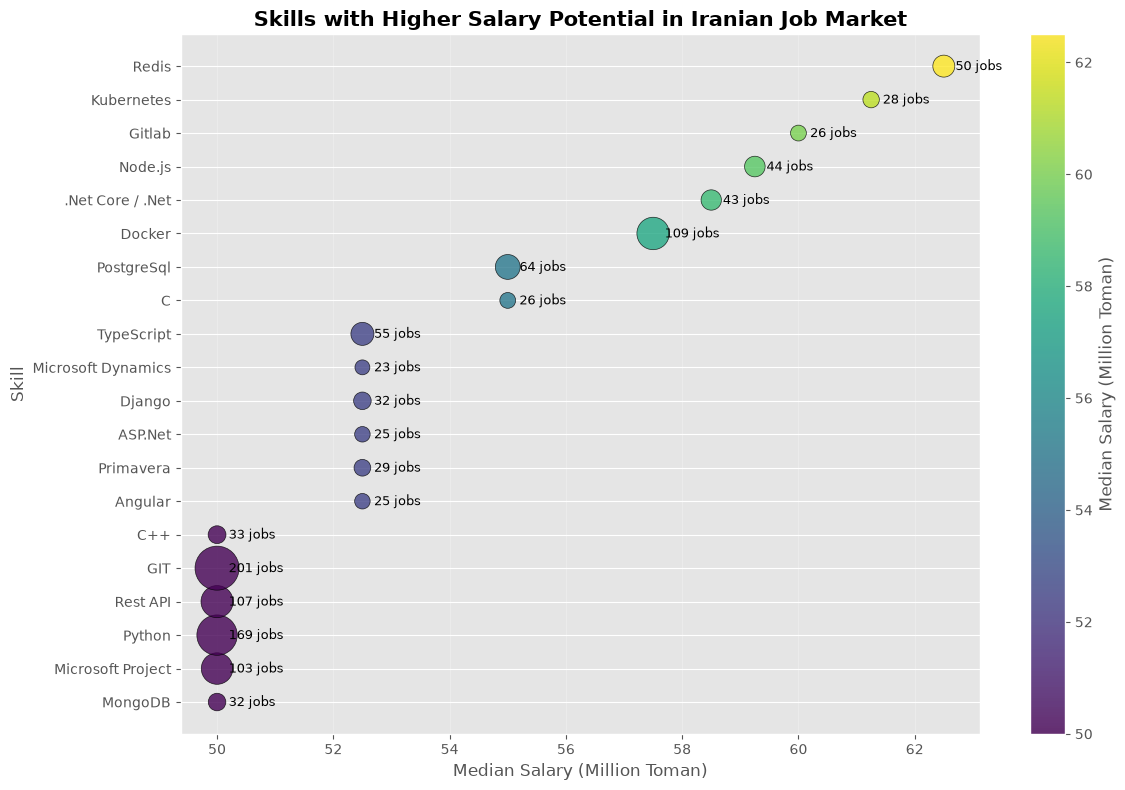

In [ ]:
plt.figure(figsize=(12,8))
scatter = plt.scatter(
    top_skills["median_salary"],
    top_skills["skill"],
    s=top_skills["count"] * 5,
    c=top_skills["median_salary"],
    cmap="viridis",
    alpha=0.8,
    edgecolor="black"
)
plt.colorbar(scatter, label="Median Salary (Million Toman)")
for _, row in top_skills.iterrows():
    plt.text(row["median_salary"] + 0.2, row["skill"], f'{row["count"]} jobs', va="center", fontsize=9)

plt.title("Skills with Higher Salary Potential in Iranian Job Market", fontsize=15, fontweight="bold")
plt.xlabel("Median Salary (Million Toman)")
plt.ylabel("Skill")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
overall_median_salary = salary_df["salary_avg"].median()
skill_salary_filtered["premium"] = (skill_salary_filtered["median_salary"] - overall_median_salary)
skill_salary_filtered.sort_values("premium", ascending=False)[:30]
# The Iranian job market rewards engineers who can build and maintain production-ready systems, not only write application code

,skill,count,median_salary,mean_salary,premium
192,Redis,50,62.50,66.880000,25.00
118,Kubernetes,28,61.25,66.303571,23.75
91,Gitlab,26,60.00,68.326923,22.50
151,Node.js,44,59.25,66.340909,21.75
0,.Net Core / .Net,43,58.50,59.558140,21.00
67,Docker,109,57.50,61.784404,20.00
174,PostgreSql,64,55.00,59.750000,17.50
35,C,26,55.00,60.384615,17.50
66,Django,32,52.50,56.625000,15.00
5,ASP.Net,25,52.50,49.800000,15.00


In [180]:
combo_df = salary_skill_df.copy()
combo_df["skill_combo"] = (combo_df["skills"].apply(lambda x: ",".join(sorted(x))))

In [ ]:
from itertools import combinations

skill_pairs = []

for idx, skills in salary_skill_df["skills"].items():
    skills = sorted(set(skills))
    for pair in combinations(skills, 2):
        skill_pairs.append(
            {
                "job_index": idx,
                "skill_1": pair[0],
                "skill_2": pair[1]
            }
        )

pairs_df = pd.DataFrame(skill_pairs)
pairs_df.head()

,job_index,skill_1,skill_2
0,6,C,Linux
1,6,C,OpenCV
2,6,C,Python
3,6,Linux,OpenCV
4,6,Linux,Python


In [184]:
pairs_salary_df = pairs_df.merge(
    salary_skill_df[
        [
            "salary_avg"
        ]
    ],
    left_on="job_index",
    right_index=True,
    how="left"
)
pairs_salary_df.head()

,job_index,skill_1,skill_2,salary_avg
0,6,C,Linux,58.5
1,6,C,OpenCV,58.5
2,6,C,Python,58.5
3,6,Linux,OpenCV,58.5
4,6,Linux,Python,58.5


In [186]:
skill_pair_salary = (
    pairs_salary_df
    .groupby(
        [
            "skill_1",
            "skill_2"
        ]
    )
    ["salary_avg"]
    .agg(
        count="count",
        median_salary="median",
        mean_salary="mean"
    )
    .reset_index()
)

skill_pair_salary_filtered = (
    skill_pair_salary[
        skill_pair_salary["count"] >= 10
    ]
    .sort_values(
        "median_salary",
        ascending=False
    )
)
skill_pair_salary_filtered.head(30)

,skill_1,skill_2,count,median_salary,mean_salary
1312,Docker,RabbitMQ,13,83.50,79.000000
1289,Docker,Kafka,10,75.25,73.450000
2998,PowerBI,راهکاران,10,75.00,79.600000
801,C#,Docker,11,67.00,70.272727
2227,Linux,Rest API,15,67.00,63.200000
2967,PostgreSql,Sql Server,14,65.75,61.464286
3031,Python,Redis,21,62.50,67.119048
2155,Kubernetes,Python,13,62.50,63.000000
2772,MySql,Redis,14,62.50,67.857143
1315,Docker,Redis,36,62.50,67.472222


In [187]:
overall_median = salary_df["salary_avg"].median()
skill_pair_salary_filtered["premium"] = (skill_pair_salary_filtered["median_salary"] - overall_median)
skill_pair_salary_filtered[:20]

,skill_1,skill_2,count,median_salary,mean_salary,premium
1312,Docker,RabbitMQ,13,83.50,79.000000,46.00
1289,Docker,Kafka,10,75.25,73.450000,37.75
2998,PowerBI,راهکاران,10,75.00,79.600000,37.50
801,C#,Docker,11,67.00,70.272727,29.50
2227,Linux,Rest API,15,67.00,63.200000,29.50
2967,PostgreSql,Sql Server,14,65.75,61.464286,28.25
3031,Python,Redis,21,62.50,67.119048,25.00
2155,Kubernetes,Python,13,62.50,63.000000,25.00
2772,MySql,Redis,14,62.50,67.857143,25.00
1315,Docker,Redis,36,62.50,67.472222,25.00


In [190]:
G = nx.Graph()
for _, row in skill_pair_salary_filtered.iterrows():
    G.add_edge(row["skill_1"], row["skill_2"], weight=row["count"])
G.number_of_nodes(), G.number_of_edges()


centrality = nx.degree_centrality(G)
top_skills_network = (
    pd.DataFrame(
        centrality.items(),
        columns=[
            "skill",
            "centrality"
        ]
    )
    .sort_values(
        "centrality",
        ascending=False
    )
)
top_skills_network[:20]

,skill,centrality
33,Microsoft Excel,0.318681
19,GIT,0.285714
41,Microsoft Word,0.263736
10,Python,0.241758
6,Linux,0.230769
0,Docker,0.219780
23,JavaScript,0.208791
9,Sql Server,0.197802
72,Wordpress,0.197802
47,Html & CSS,0.197802


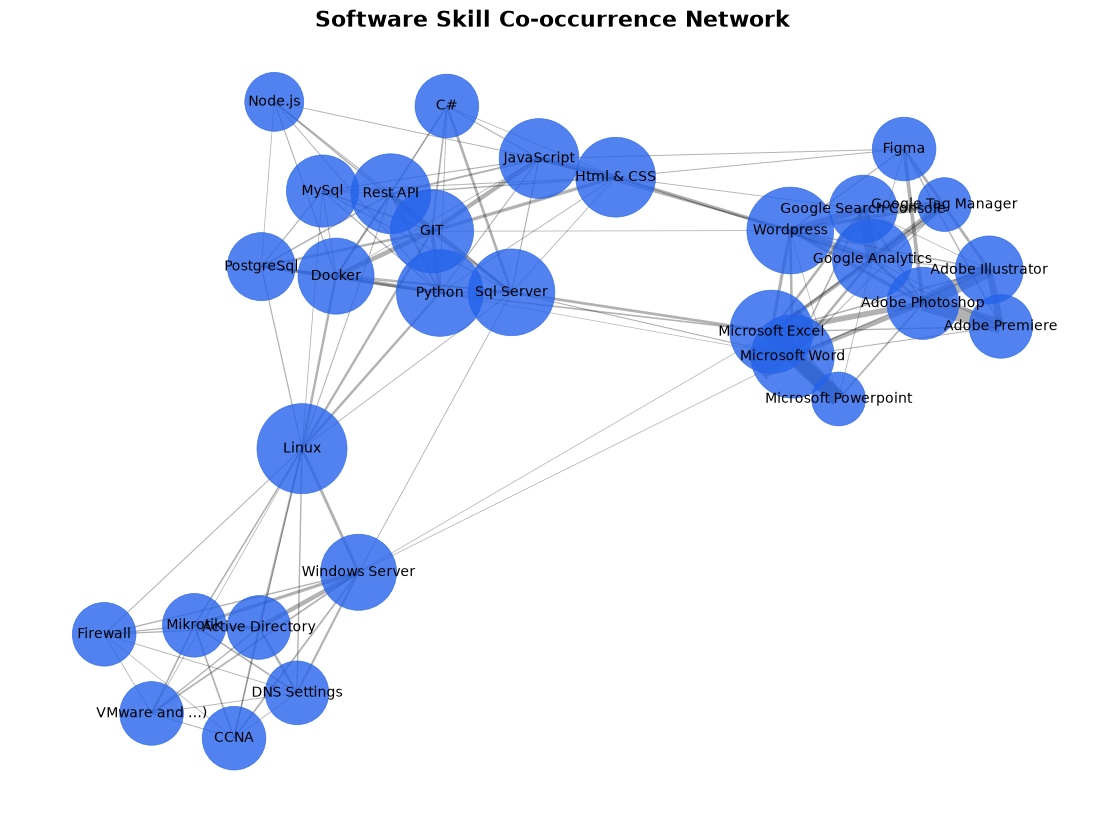

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
top_nodes = (
    top_skills_network
    .head(30)["skill"]
    .tolist()
)

G_sub = G.subgraph(top_nodes)


pos = nx.spring_layout(
    G_sub,
    k=1,
    seed=42
)


node_sizes = [
    G_sub.degree(node) * 300
    for node in G_sub.nodes()
]


edge_widths = [
    G_sub[u][v]["weight"] / 20
    for u, v in G_sub.edges()
]


nx.draw_networkx_nodes(
    G_sub,
    pos,
    node_size=node_sizes,
    node_color="#2563EB",
    alpha=0.8
)


nx.draw_networkx_edges(
    G_sub,
    pos,
    width=edge_widths,
    alpha=0.3
)


nx.draw_networkx_labels(
    G_sub,
    pos,
    font_size=10
)


plt.title(
    "Software Skill Co-occurrence Network",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.show()

### Key Findings

- Skill combinations provide stronger signals of market value compared with individual skills, as employers usually look for combinations of technical capabilities rather than isolated technologies.

- Production-oriented engineering stacks show the highest salary premiums. Combinations such as Docker + RabbitMQ, Docker + Kafka, and Docker + Redis are associated with significantly higher median salaries, indicating strong demand for engineers who can build and maintain scalable systems.

- Backend engineering skills demonstrate a clear value pattern. Combinations involving programming languages, databases, and infrastructure technologies (such as Python + Redis, Docker + PostgreSQL, and PostgreSQL + Redis) consistently appear among higher-paying skill combinations.

- Docker acts as a salary multiplier rather than an independent skill. While Docker alone is associated with higher salaries, its combination with technologies such as Python, Redis, Kubernetes, and messaging systems creates significantly higher market value.

- Database and infrastructure skills have strong salary impact. Technologies such as Redis, PostgreSQL, Kubernetes, and Docker frequently appear in high-paying combinations, suggesting that companies place a premium on candidates who understand production-level systems.

- The analysis suggests that career growth is driven not only by learning individual technologies but also by developing complementary skill stacks. For example, a Python developer can increase market competitiveness by adding backend frameworks, database technologies, and deployment skills.

- Skill combination analysis provides valuable insights for recommendation systems, as it enables identifying the most valuable next skills for candidates based on their existing skill set and current market demand.